# 树

## 二叉树（binary tree）
叉树（binary tree）是一种非线性数据结构，代表“祖先”与“后代”之间的派生关系，体现了 **“一分为二”的分治逻辑** 。与链表类似，二叉树的基本单元是节点，每个节点包含值、左子节点引用和右子节点引用。

In [1]:
class TreeNode:
    """二叉树节点类"""
    def __init__(self, val: int):
        self.val: int = val                # 节点值
        self.left: TreeNode | None = None  # 左子节点引用
        self.right: TreeNode | None = None # 右子节点引用

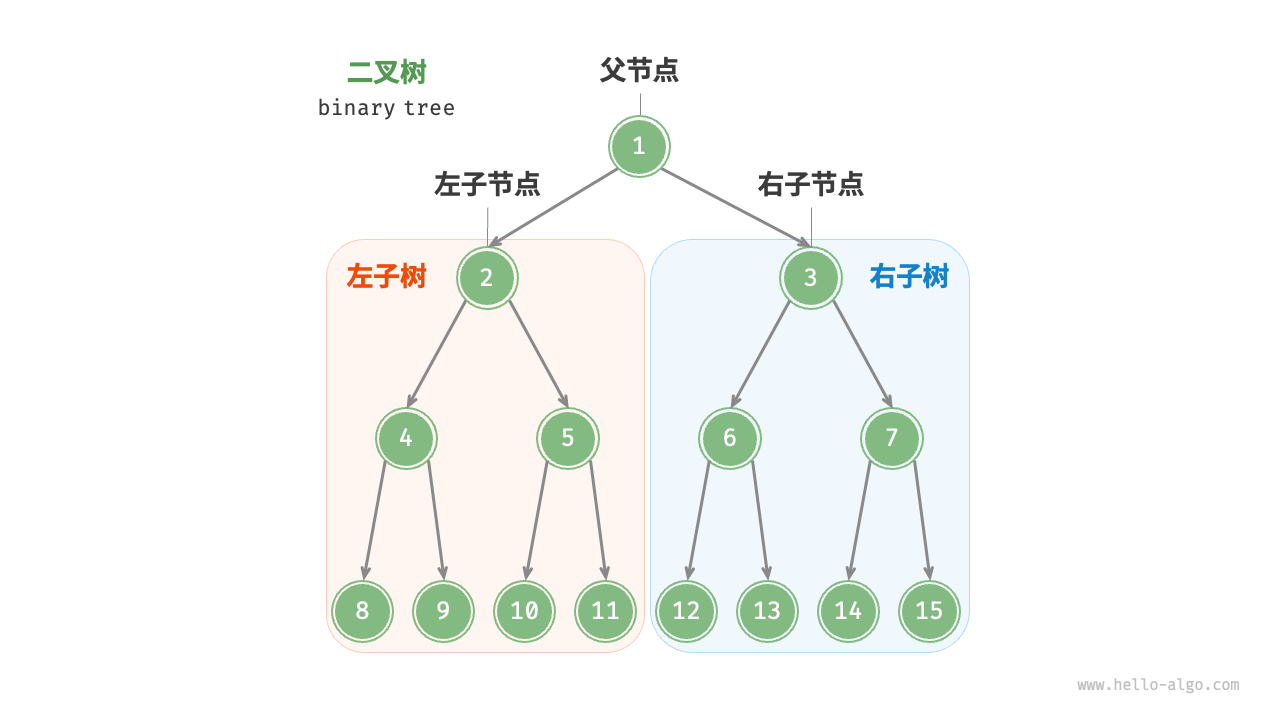

在二叉树中，**除叶节点外，其他所有节点都包含子节点和非空子树**。

二叉树的常用术语如图 7-2 所示。

- 根节点（root node）：位于二叉树顶层的节点，没有父节点。
- 叶节点（leaf node）：没有子节点的节点，其两个指针均指向 None 。
- 边（edge）：连接两个节点的线段，即节点引用（指针）。
- 节点所在的层（level）：从顶至底递增，根节点所在层为 1 。
- 节点的度（degree）：节点的子节点的数量。在二叉树中，度的取值范围是 0、1、2 。
- 二叉树的高度（height）：从根节点到最远叶节点所经过的边的数量。
- 节点的深度（depth）：从根节点到该节点所经过的边的数量。
- 节点的高度（height）：从距离该节点最远的叶节点到该节点所经过的边的数量。

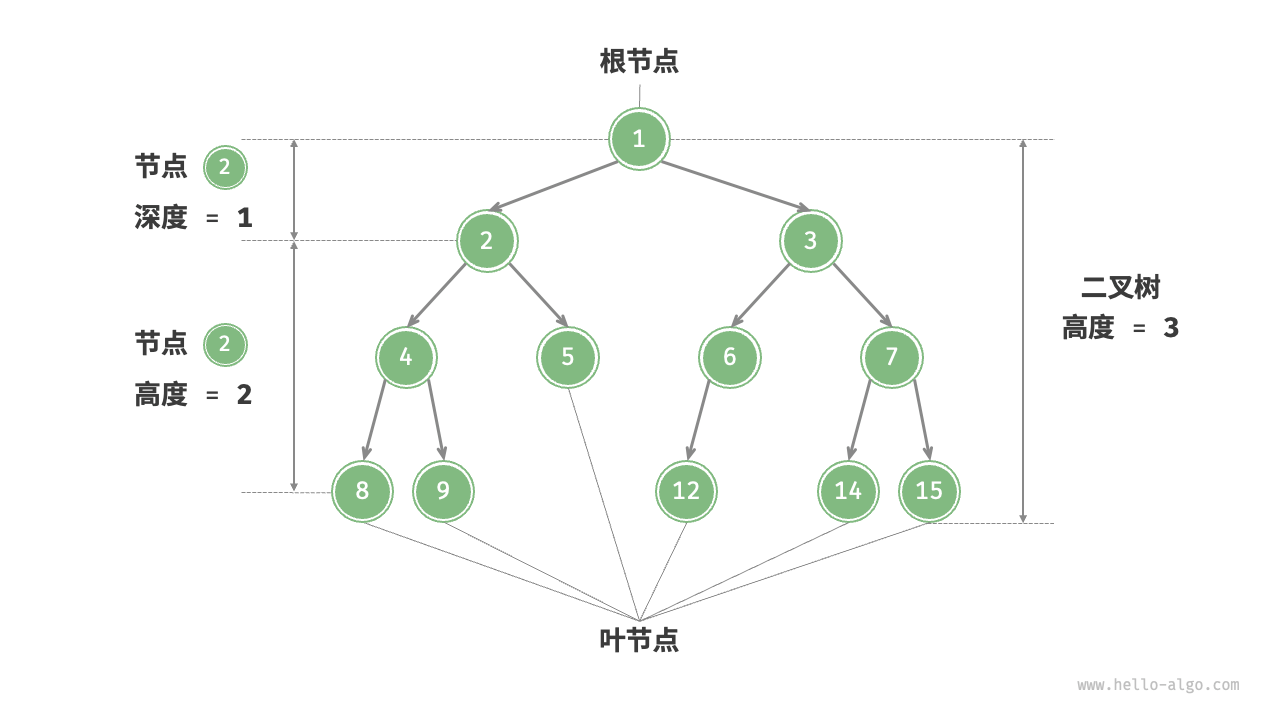


# 初始化和插入删除



In [2]:
# 初始化二叉树
# 初始化节点
n1 = TreeNode(val=1)
n2 = TreeNode(val=2)
n3 = TreeNode(val=3)
n4 = TreeNode(val=4)
n5 = TreeNode(val=5)
# 构建节点之间的引用（指针）

n1.left = n2
n1.right = n3
n2.left = n4
n2.right = n5

In [3]:
# 插入与删除节点
p = TreeNode(0)
# 在 n1 -> n2 中间插入节点 P
n1.left = p
p.left = n2
# 删除节点 P
n1.left = n2

需要注意的是，**插入节点**可能会改变二叉树的**原有逻辑结构**，而删除节点通常意味着**删除该节点及其所有子树**。因此，在二叉树中，插入与删除通常是由一套操作配合完成的，以实现有实际意义的操作。

## 常见二叉树类型

1. 完美二叉树（perfect binary tree）所有层的节点都被完全填满。
- 请注意，在中文社区中，完美二叉树常被称为满二叉树。

2. 完全二叉树（complete binary tree）仅允许最底层的节点不完全填满，且最底层的节点必须从左至右依次连续填充。

3. 完满二叉树（full binary tree）除了叶节点之外，其余所有节点都有两个子节点。

4. 平衡二叉树（balanced binary tree）中任意节点的左子树和右子树的高度之差的绝对值不超过 1 。


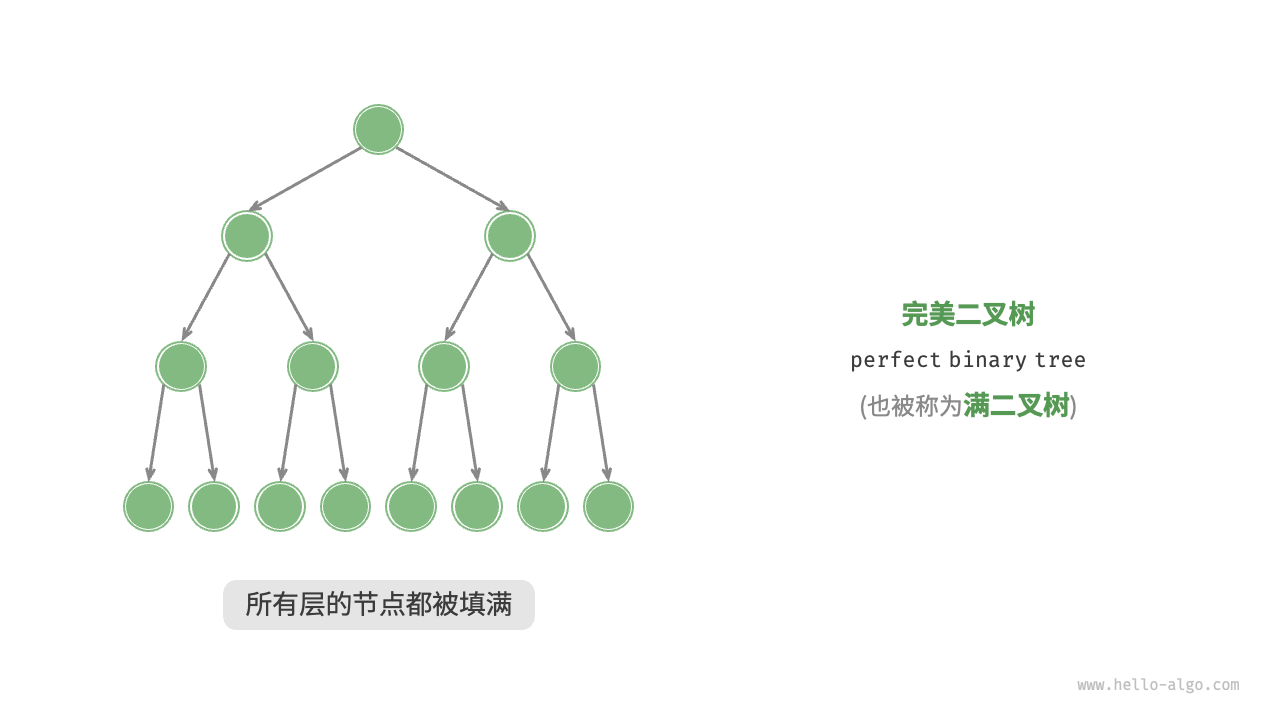

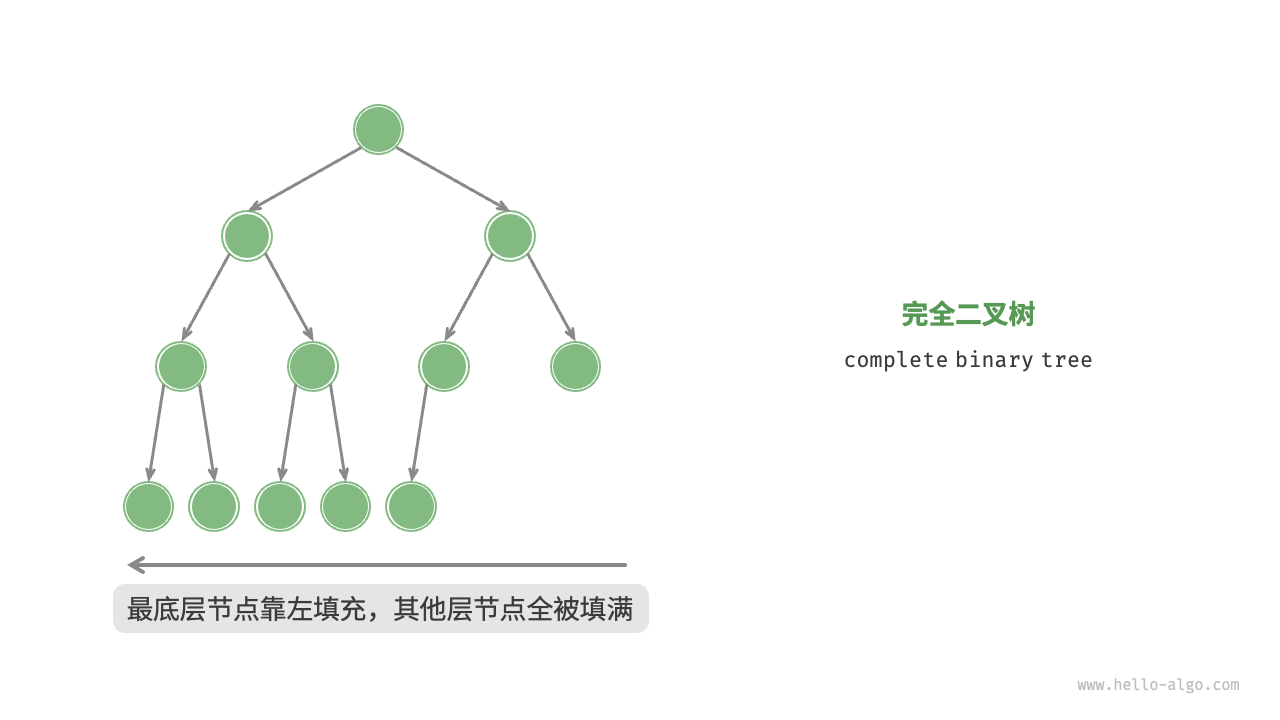

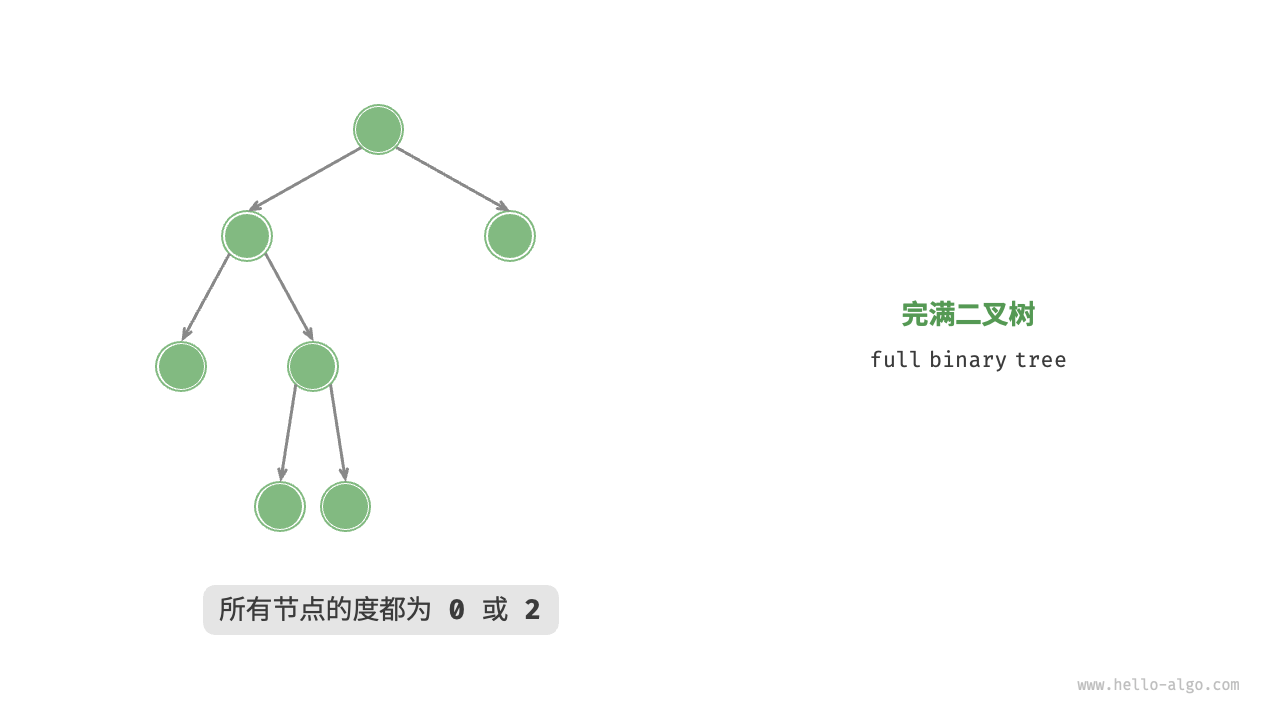

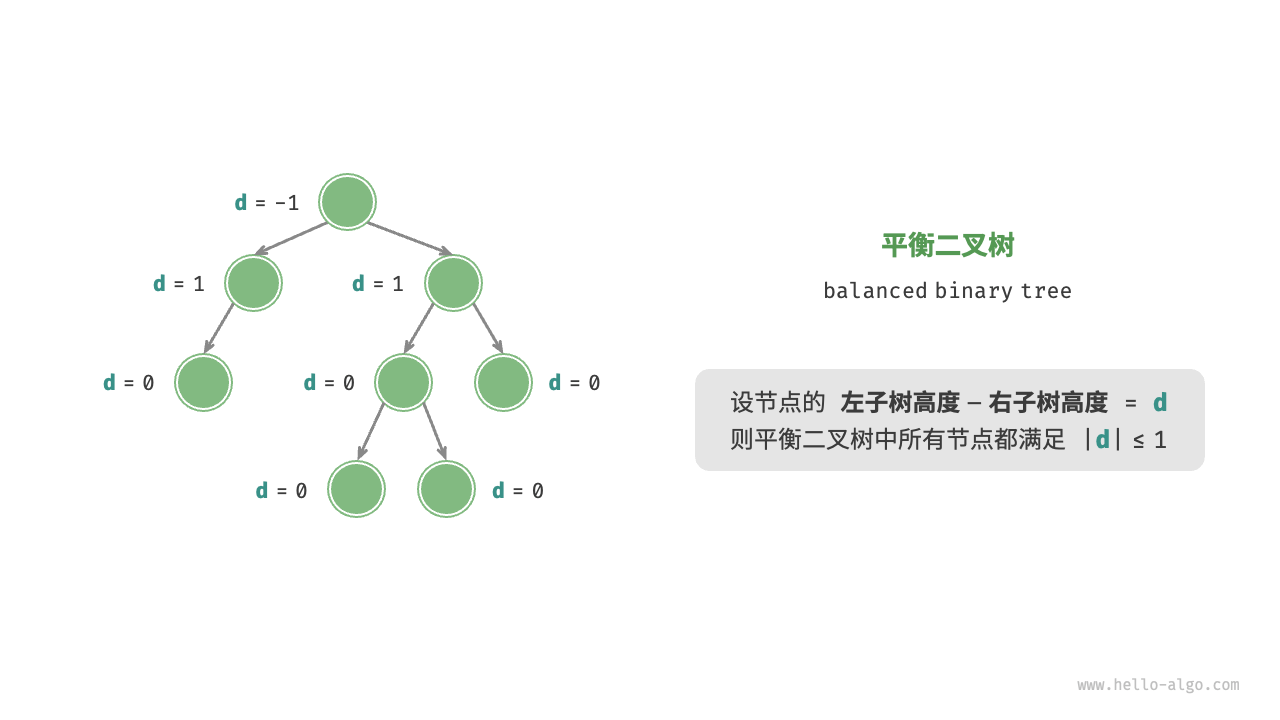

- 退化

二叉树的理想结构与退化结构。当二叉树的每层节点都被填满时，达到“完美二叉树”；而当所有节点都偏向一侧时，二叉树退化为“链表”。

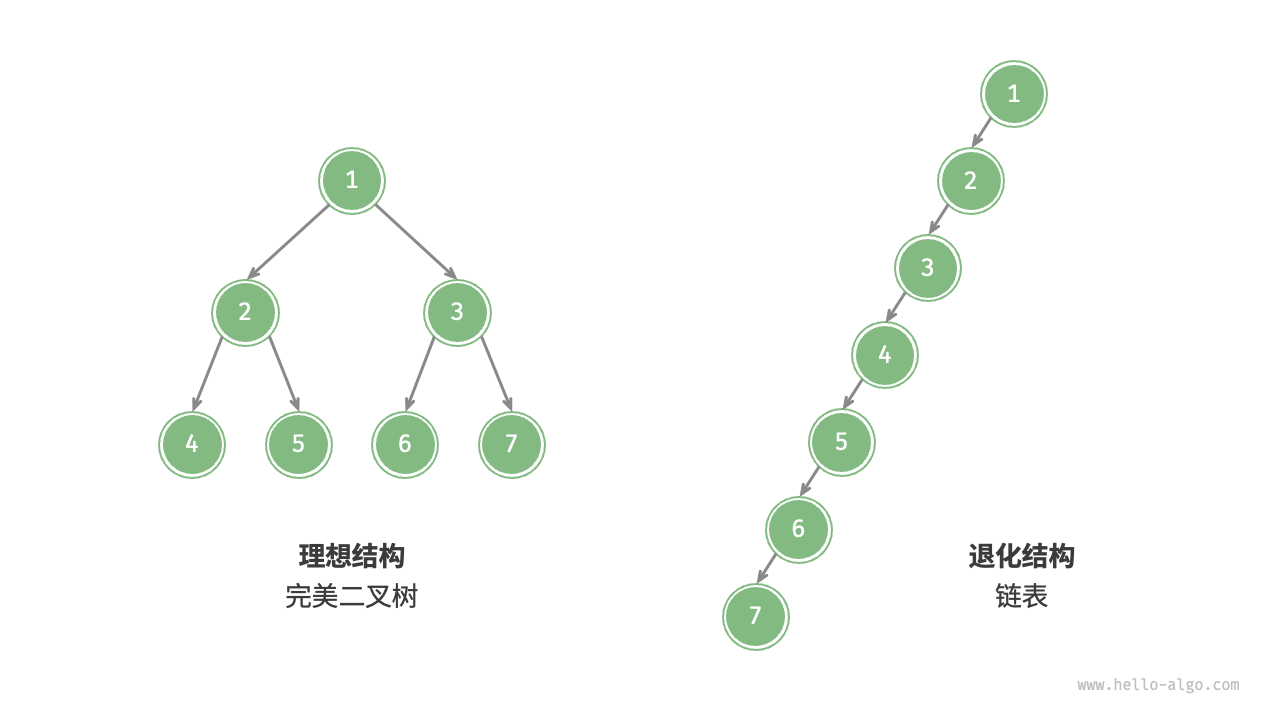

完美二叉树是理想情况，可以充分发挥二叉树“分治”的优势。
链表则是另一个极端，各项操作都变为线性操作，时间复杂度退化至 
 。

## 二叉树的遍历

从物理结构的角度来看，树是一种基于链表的数据结构，因此其遍历方式是通过指针逐个访问节点。然而，树是一种非线性数据结构，这使得遍历树比遍历链表更加复杂，**需要借助搜索算法来实现**。

- 层序遍历、
- 前序遍历、
- 中序遍历和后序遍历等。

In [5]:
from collections import deque

class TreeNode:
    """二叉树节点类"""
    def __init__(self, val: int):
        self.val: int = val                # 节点值
        self.left: TreeNode | None = None  # 左子节点引用
        self.right: TreeNode | None = None # 右子节点引用

def level_order(root: TreeNode | None) -> list[int]:
    """层序遍历"""
    # 初始化队列，加入根节点
    queue: deque[TreeNode] = deque()
    queue.append(root)
    # 初始化一个列表，用于保存遍历序列
    res = []
    while queue:
        node: TreeNode = queue.popleft()  # 队列出队
        res.append(node.val)  # 保存节点值
        if node.left is not None:
            queue.append(node.left)  # 左子节点入队
        if node.right is not None:
            queue.append(node.right)  # 右子节点入队
    return res

In [7]:
res = []

def pre_order(root: TreeNode | None):
    """前序遍历"""
    if root is None:
        return
    # 访问优先级：根节点 -> 左子树 -> 右子树
    res.append(root.val)
    pre_order(root=root.left)
    pre_order(root=root.right)

def in_order(root: TreeNode | None):
    """中序遍历"""
    if root is None:
        return
    # 访问优先级：左子树 -> 根节点 -> 右子树
    in_order(root=root.left)
    res.append(root.val)
    in_order(root=root.right)

def post_order(root: TreeNode | None):
    """后序遍历"""
    if root is None:
        return
    # 访问优先级：左子树 -> 右子树 -> 根节点
    post_order(root=root.left)
    post_order(root=root.right)
    res.append(root.val)

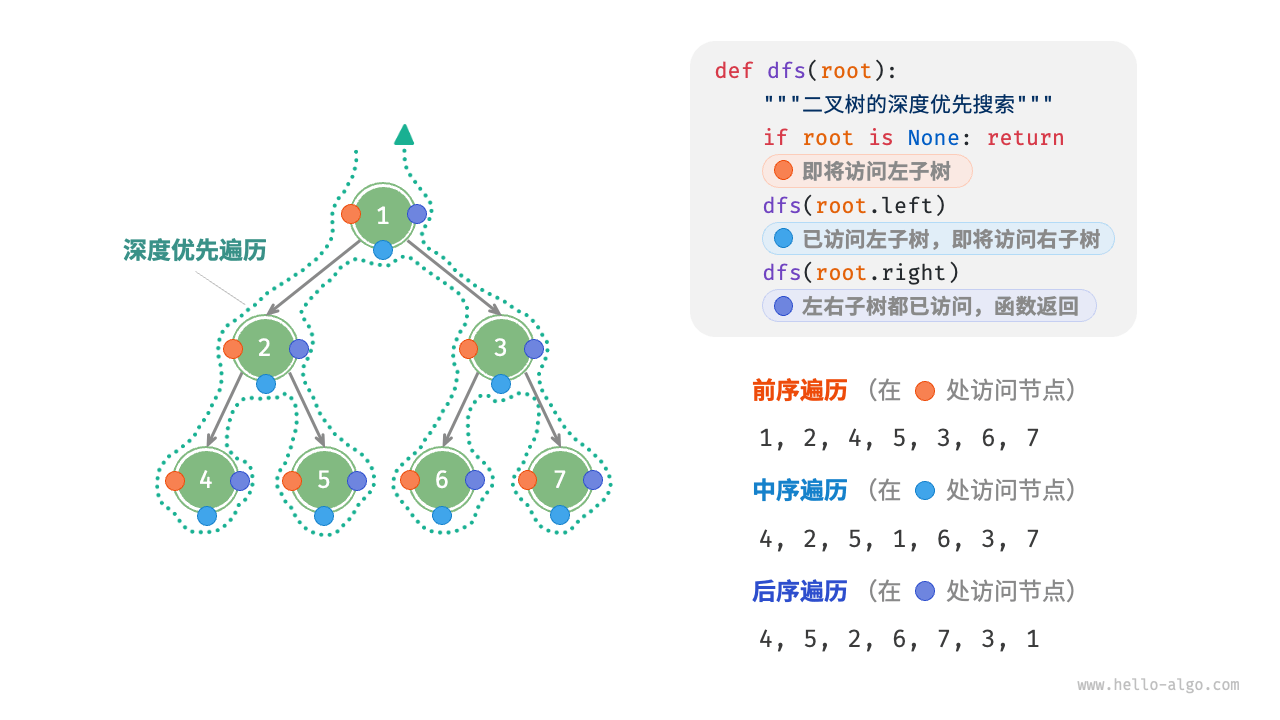

## 二叉树的数组表示

给定一棵完美二叉树，我们将所有节点按照层序遍历的顺序存储在一个数组中，则每个节点都对应唯一的数组索引。

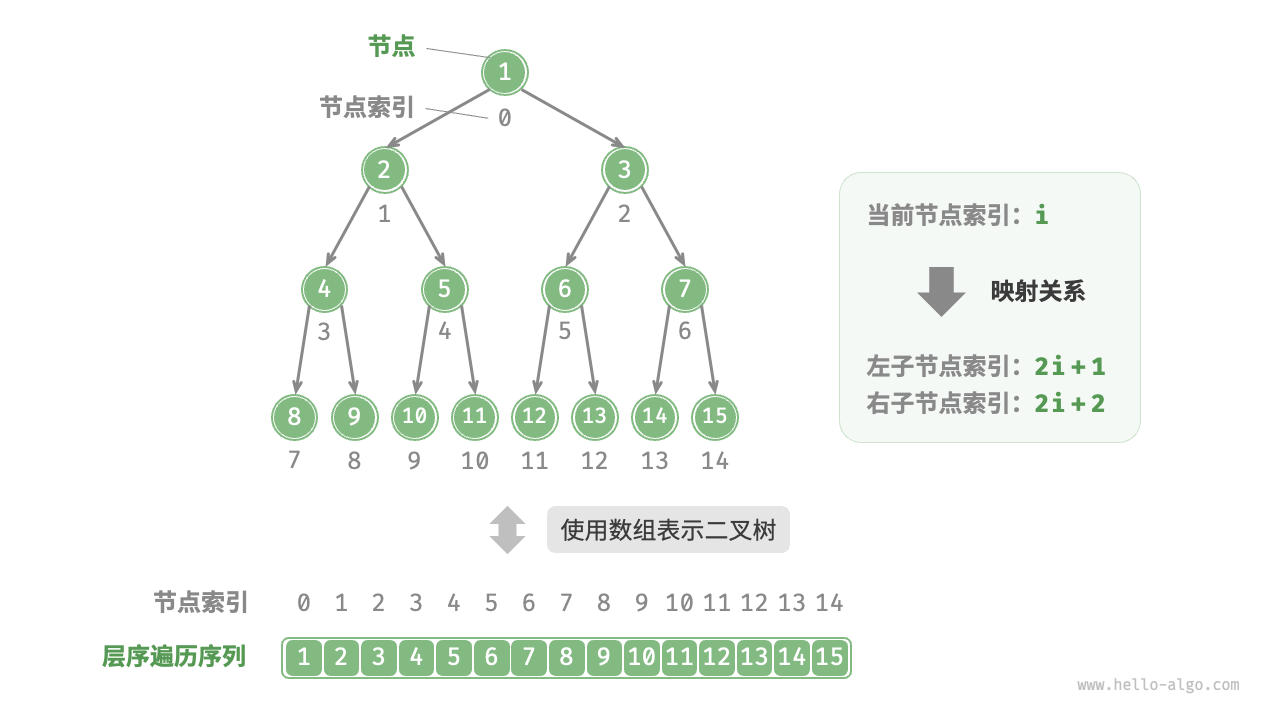